In [ ]:
!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

# 1. Ma'lumotni yuklash (ID: 544)
d = fetch_ucirepo(id=544)
df = pd.concat([d.data.features, d.data.targets], axis=1)



Vazn va Yoshi o'rtasidagi bog'liqlik VISUALIZATION

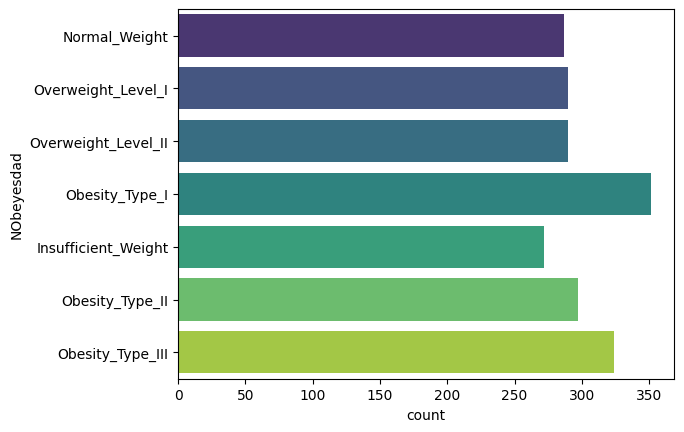

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Maqsadli ustun taqsimoti
target = df.columns[-1]
sns.countplot(y=target, data=df, hue=target, palette='viridis', legend=False)
plt.show()



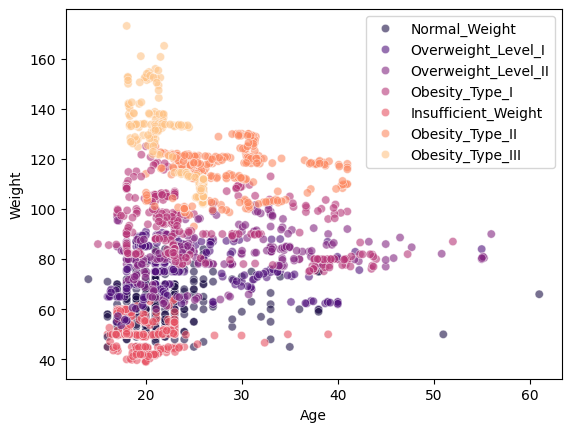

In [ ]:
# 2. Vazn va Yoshi o'rtasidagi bog'liqlik
# Ranglar orqali semizlik darajasini ko'ramiz
sns.scatterplot(x='Age', y='Weight', hue=target, data=df, palette='magma', alpha=0.6)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

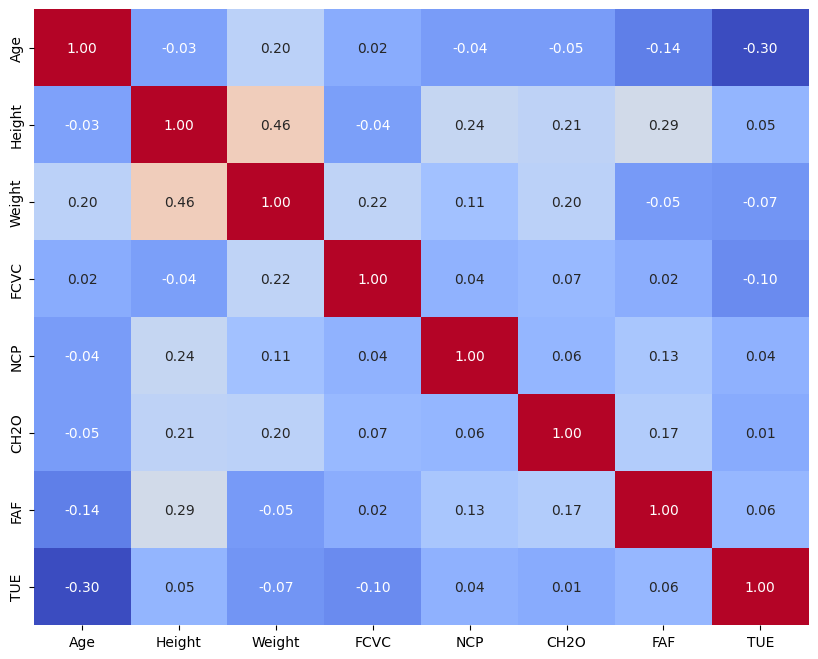

In [ ]:

# 3. Korrelyatsiya matritsasi
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.show()

Preprocessing

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# 1. Ma'lumotlarni ajratish
X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

# 2. Targetni raqamga o'girish (7 ta klass: 0-6)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Ustunlarni turiga qarab saralash
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# 4. Transformator (Scaling va Encoding bir joyda)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 5. O'qitish va Test to'plamiga bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 6. Ma'lumotlarni modelga tayyor holatga keltirish
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)



Bagging va Boosting modellarini qurish

In [ ]:
!pip install catboost -q # Boosting uchun CatBoost kutubxonasi
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# 1. Bagging (Random Forest)
bagging_model = RandomForestClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train_final, y_train)

# 2. Boosting (CatBoost)
boosting_model = CatBoostClassifier(iterations=500, verbose=0, random_state=42)
boosting_model.fit(X_train_final, y_train)

# Natijalarni tekshirish
bag_pred = bagging_model.predict(X_test_final)
boost_pred = boosting_model.predict(X_test_final)

print(f"Bagging Accuracy: {accuracy_score(y_test, bag_pred):.4f}")
print(f"Boosting Accuracy: {accuracy_score(y_test, boost_pred):.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
Bagging Accuracy: 0.9314
Boosting Accuracy: 0.9598


Voting Classifier

In [ ]:
from sklearn.ensemble import VotingClassifier

#Voting modelini yaratish
voting_model = VotingClassifier(
    estimators=[
        ('rf', bagging_model),
        ('cb', boosting_model)
    ],
    voting='soft'
)

# Modelni o'qitish
voting_model.fit(X_train_final, y_train)

#Natijani tekshirish
voting_pred = voting_model.predict(X_test_final)
print(f"Voting Accuracy: {accuracy_score(y_test, voting_pred):.4f}")

Voting Accuracy: 0.9645


Stacking Classifier

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

#Stacking modelini yaratish
stacking_model = StackingClassifier(
    estimators=[
        ('rf', bagging_model),
        ('cb', boosting_model)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

#  Modelni o'qitish
stacking_model.fit(X_train_final, y_train)

# Natijani tekshirish
stacking_pred = stacking_model.predict(X_test_final)
print(f"Stacking Accuracy: {accuracy_score(y_test, stacking_pred):.4f}")

Stacking Accuracy: 0.9622


Confusion Matrix

Modellar solishtiruvi:


,Metod,Accuracy
0,Bagging (RF),0.9314
1,Boosting (CB),0.9598
2,Stacking,0.9622
3,Voting,0.9645


<Figure size 1000x800 with 0 Axes>

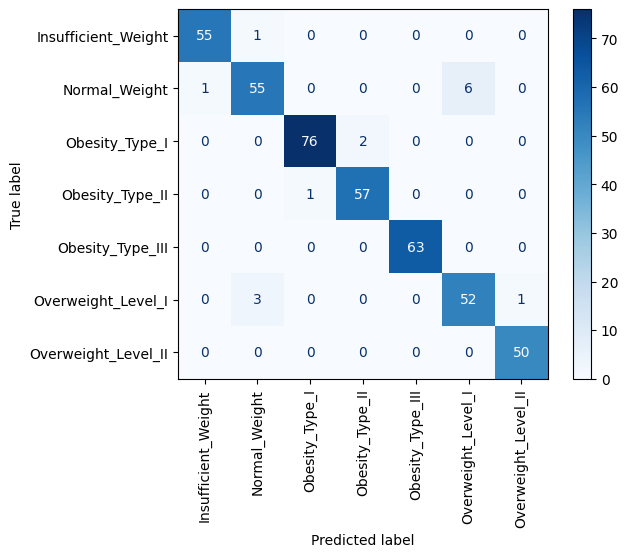

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# Modellarni solishtirish jadvali
results = {
    "Metod": ["Bagging (RF)", "Boosting (CB)", "Stacking", "Voting"],
    "Accuracy": [0.9314, 0.9598, 0.9622, 0.9645]
}
results_df = pd.DataFrame(results)
print("Modellar solishtiruvi:")
display(results_df)

# Eng yaxshi model Votin uchun Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, voting_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.show()

boosting uchun SHAP

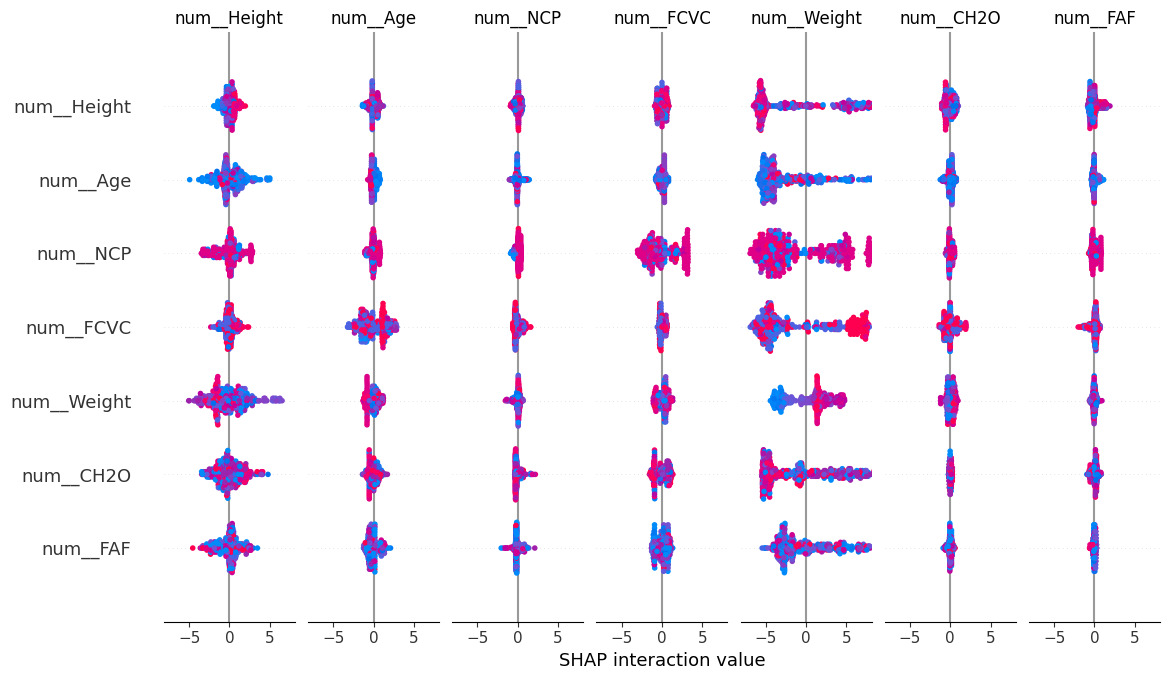

In [ ]:
# --- SHAP Tahlili ---
!pip install shap -q
import shap

# Boosting modelimiz (CatBoost) uchun tushuntiruvchi yaratamiz
explainer = shap.TreeExplainer(boosting_model)
shap_values = explainer.shap_values(X_test_final)

# Grafikni chizish
shap.summary_plot(shap_values, X_test_final, feature_names=preprocessor.get_feature_names_out())

Classification Report (Aniqroq metrikalar)

In [ ]:
from sklearn.metrics import classification_report

# Voting model uchun to'liq hisobot
print("To'liq klassifikatsiya hisoboti:")
print(classification_report(y_test, voting_pred, target_names=le.classes_))

To'liq klassifikatsiya hisoboti:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        56
      Normal_Weight       0.93      0.89      0.91        62
     Obesity_Type_I       0.99      0.97      0.98        78
    Obesity_Type_II       0.97      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.90      0.93      0.91        56
Overweight_Level_II       0.98      1.00      0.99        50

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



Feature Importance (Faktorlar muhimligi)

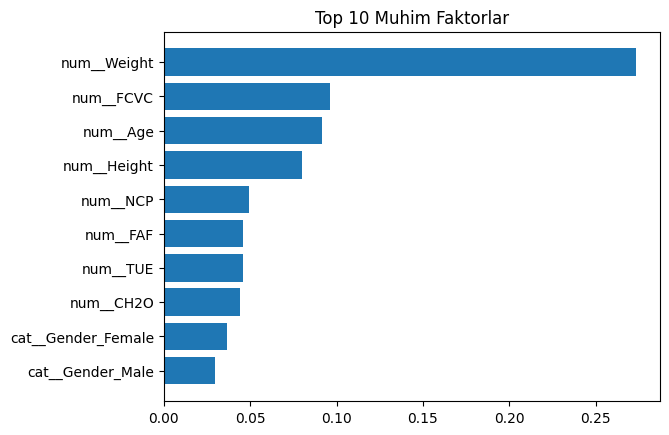

In [ ]:
# Random Forest (Bagging) uchun faktorlar muhimligi
import numpy as np

features = preprocessor.get_feature_names_out()
importances = bagging_model.feature_importances_
indices = np.argsort(importances)[-10:] # Eng muhim 10 ta faktor

plt.title('Top 10 Muhim Faktorlar')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.show()